In [69]:
import pandas as pd
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

In [70]:
df=pd.read_csv(r"C:\Users\shaiv\Downloads\data analytics projects\bayesian_ab_testing_platform\data\experiments/ab_experiment_dataset.csv")

In [71]:
len(df)

99992

In [72]:
#traffic checkpoints result at 10% traffic, 20% traffic -- 100% traffic
traffic_checkpoints=[
    0.01,
    0.02,
    0.05,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40,
    0.50,
    1.00
]

In [73]:
#storage lists
winning_probabilities=[]
traffic_percentages=[]

In [74]:
#create partial datasets for each percent of traffic
for percent in traffic_checkpoints:
    sample_size=int(len(df)*percent)
    partial_df = df.sample(sample_size, random_state=42)
    variant_a=partial_df[partial_df["variant"]=="A"]
    variant_b=partial_df[partial_df["variant"]=="B"]
    #count conversions and failures
    success_a=variant_a["converted"].sum()
    failure_a=len(variant_a)-success_a
    success_b=variant_b["converted"].sum()
    failure_b=len(variant_b)-success_b
    #prior belief beta distribution
    alpha_prior=1
    beta_prior=1
    alpha_b=alpha_prior+success_b
    beta_b=beta_prior+failure_b
    #out of 100,000 believable worlds, how often does B beat A?
    samples_a=np.random.beta(
        alpha_a,
        beta_a,
        100000
    )
    samples_b=np.random.beta(
        alpha_b,
        beta_b,
        100000
    )
    prob_b_better=np.mean(samples_b>samples_a)
    winning_probabilities.append(prob_b_better)
    traffic_percentages.append(percent*100)

    conv_a = variant_a["converted"].mean()
    conv_b = variant_b["converted"].mean()

    print(
        f"{percent*100:.0f}% | "
        f"A={conv_a:.4f} | "
        f"B={conv_b:.4f}"
    )

1% | A=0.0620 | B=0.1013
2% | A=0.0715 | B=0.0977
5% | A=0.0719 | B=0.0971
10% | A=0.0678 | B=0.0994
15% | A=0.0670 | B=0.0993
20% | A=0.0683 | B=0.0969
30% | A=0.0680 | B=0.0979
40% | A=0.0672 | B=0.0985
50% | A=0.0685 | B=0.0989
100% | A=0.0661 | B=0.0981


In [75]:
results_df = pd.DataFrame({
    "Traffic Percentage":
    traffic_percentages,

    "Probability B Wins":
    winning_probabilities
})
results_df

,Traffic Percentage,Probability B Wins
0,1.0,0.99193
1,2.0,0.99821
2,5.0,0.99999
3,10.0,1.00000
4,15.0,1.00000
5,20.0,1.00000
6,30.0,1.00000
7,40.0,1.00000
8,50.0,1.00000
9,100.0,1.00000


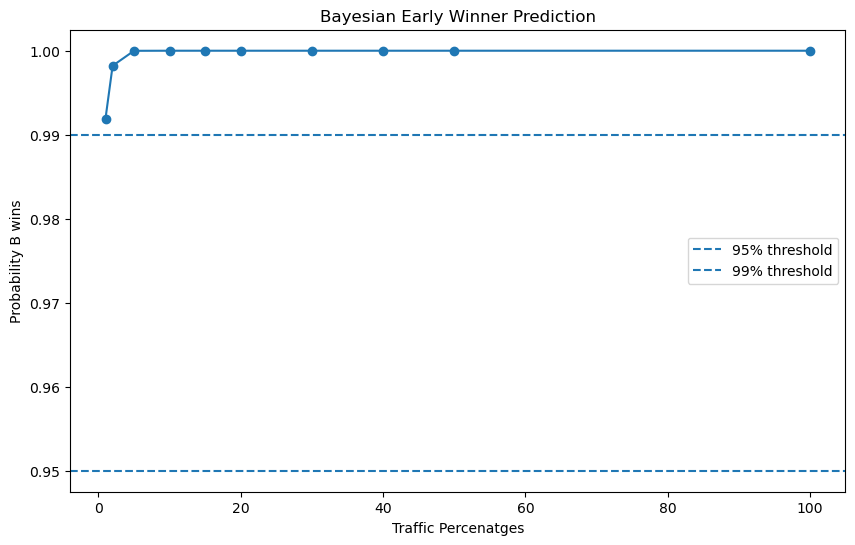

In [76]:
plt.figure(figsize=(10,6))
plt.plot(
    traffic_percentages,
    winning_probabilities,
    marker="o")
plt.axhline(
    0.95,
    linestyle="--",
    label="95% threshold"
)
plt.axhline(
    0.99,
    linestyle="--",
    label="99% threshold"
)

plt.xlabel("Traffic Percenatges")
plt.ylabel("Probability B wins")
plt.title("Bayesian Early Winner Prediction")
plt.legend()
plt.show()



In [86]:
results_df[results_df["Probability B Wins"]>0.95]

,Traffic Percentage,Probability B Wins
0,1.0,0.99193
1,2.0,0.99821
2,5.0,0.99999
3,10.0,1.00000
4,15.0,1.00000
5,20.0,1.00000
6,30.0,1.00000
7,40.0,1.00000
8,50.0,1.00000
9,100.0,1.00000


In [92]:
early_stop=results_df[results_df["Probability B Wins"]>0.95].iloc[0]

In [94]:
print(
    "Early Stop Traffic:",
    early_stop[
        "Traffic Percentage"
    ]
)

Early Stop Traffic: 1.0


In [102]:
total_users=len(df)
users_needed=int(total_users*early_stop["Traffic Percentage"]/100)

In [104]:
saved_users=total_users-users_needed

In [108]:
print(
    "Users Saved:",
    saved_users,
    "Total Users:",
    total_users
)

Users Saved: 98993 Total Users: 99992
